In [7]:
import pandas as pd
import numpy as np

rawdata = pd.read_csv('./data/rawdata/sdi_output.csv')
rawdata["date"] = pd.to_datetime(rawdata["date"])
rawdata.set_index("date", inplace=True)
# order based on the index
rawdata.sort_index(inplace=True)
rawdata

,sdi_A,sdi_B
date,,
2024-02-06,3.80,3.70
2024-02-07,4.19,NaN
2024-02-08,3.19,3.90
2024-02-10,3.80,3.40
2024-02-11,3.07,3.32
...,...,...
2025-01-23,NaN,NaN
2025-01-25,1.63,1.57
2025-01-26,1.50,1.47


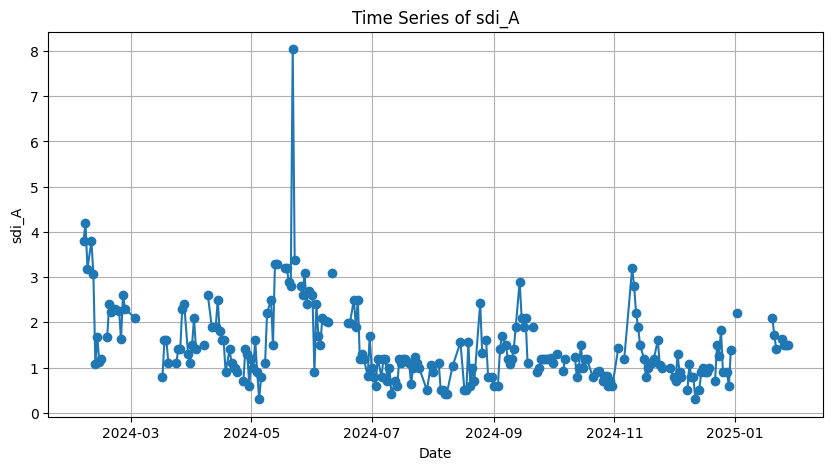

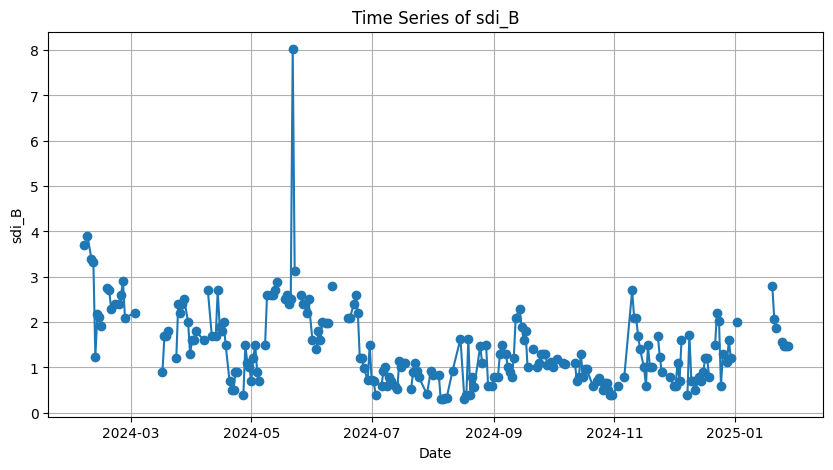

In [8]:
# time evolution of the two values
import matplotlib.pyplot as plt
for col in rawdata.columns:
    if col != 'DATE':
        plt.figure(figsize=(10, 5))
        plt.plot(rawdata.index, rawdata[col], marker='o')
        plt.title(f'Time Series of {col}')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.grid()
        plt.show()


In [9]:
rawdata[rawdata["sdi_B"] > 7]

,sdi_A,sdi_B
date,,
2024-05-22,8.04,8.02


In [11]:
# create a dataframe with continuous time series
date_range = pd.date_range(start="2024-02-01", end="2025-01-31", freq='D')
# create a dataframe with the date range
continuous_df = pd.DataFrame(date_range, columns=['date'])
continuous_df.set_index('date', inplace=True)
continuous_df

""
date
2024-02-01
2024-02-02
2024-02-03
2024-02-04
2024-02-05
...
2025-01-27
2025-01-28
2025-01-29


In [12]:
# merge the two dataframes on the index
merged_df = continuous_df.merge(rawdata, left_index=True, right_index=True, how='left')
merged_df

,sdi_A,sdi_B
date,,
2024-02-01,NaN,NaN
2024-02-02,NaN,NaN
2024-02-03,NaN,NaN
2024-02-04,NaN,NaN
2024-02-05,NaN,NaN
...,...,...
2025-01-27,1.5,1.47
2025-01-28,1.5,1.47
2025-01-29,NaN,NaN


In [14]:
merged_df.to_csv('./data/clean/sdi_cleaned_data.csv', index=True)